# Raman Spectroscopy Data Analysis: Tripeptides

This notebook demonstrates the numerical analysis for tripeptides.

## Dataset Overview
- **Source**: Raman spectroscopy measurements of tripeptide powders
- **Laser**: 532nm
- **Samples**: GAR (Glycine-Alanine-Arginine), SRA (Serine-Arginine-Alanine)
- **Format**: Tab-separated text files with wavenumber and intensity data

## Import required tools and functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from spectra import SpectraCollection, Spectrum
from spectra import read_spectrum_file, read_simple_spectrum
from spectra import subtract_baseline_arpls, subtract_baseline_als, PreprocessingPipeline, normalize_minmax, calculate_snr, Spectrum
from spectra import calculate_snr, export_to_npz

# Set random seed for reproducible example selection
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

def get_txt_filepath(name, root='./data/raw/tripeptides'):
    """Get file paths for tripeptide spectra data.
    
    Args:
        name: Tripeptide name (e.g., 'GAR', 'SRA')
        root: Root directory for raw tripeptide data
    
    Returns:
        tuple: (collection_path, test_spectrum_path)
    """
    folder = Path(root) / name
    filenames = list(folder.glob('*.txt'))

    collection_path = None
    test_spectrum_path = None
    if len(filenames) > 0:
        for filename in filenames:
            if 'test' in filename.stem.lower():
                test_spectrum_path = filename
            if 'power' in filename.stem.lower():
                collection_path = filename
    return collection_path, test_spectrum_path

def get_fingerprint(collection, threshold=50):
    snr = calculate_snr(collection)
    intensities = collection.to_intensity_matrix()
    mean_intensity = intensities[snr>threshold, :].mean(axis=0)
    fingerprint = Spectrum(np.stack((collection.wavelengths, mean_intensity), axis=1))
    return fingerprint

def plot_colletion_and_test_spectrum(collection, test_spectrum, title=' Raman Spectroscopy Data'):
    # visualise raw data
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))
    
    if collection:
       mean_intensities = collection.to_intensity_matrix().mean(axis=0)
       ax1.plot(collection.wavelengths, mean_intensities,
               'k-', linewidth=1.5, label='Fingerprint')
        
    if test_spectrum:
        ax1.plot(test_spectrum.wavelengths, test_spectrum.intensities,
                 'g-', linewidth=1.5, alpha=1, label='Test Spectrum')
        
    ax1.set_xlabel('Wavenumber (cm\u207b\u00b9)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title(title)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Data Structure

The spectra package handles two file formats:

### 1. Simple Format (2 columns)
Single spectrum per file with `#Wave` and `#Intensity` columns:
```
#Wave        #Intensity
1925.662109  217.207626
1924.119141  189.444244
...
```

### 2. Mapped Format (4 columns)
Multiple spectra per file with spatial coordinates `#X`, `#Y`, `#Wave`, `#Intensity`:
```
#X            #Y            #Wave        #Intensity
-10007.539247 -13426.202300 1925.662109  129.018066
-10007.539247 -13426.202300 1924.119141  130.651199
...
```

New spectra are detected when the X coordinate changes.

### Key Properties
- **Wavenumber range**: ~157 to ~1925 cm⁻¹
- **Points per spectrum**: 1023
- **Wavelength order**: Stored in ascending order (low to high)

In [2]:
def process_pipeline(name, save_npz=True, save_dir=Path('./data/tripeptides')):
    """Process tripeptide spectra data through the analysis pipeline.
    
    Args:
        name: Tripeptide name (e.g., 'GAR', 'SRA')
        save_npz: Whether to save processed data as .npz files
        save_dir: Directory to save processed files
    """
    save_dir = save_dir / name
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # IO: read raw txt files for Raman Spectroscopy Data
    collection_path, test_spectrum_path = get_txt_filepath(name, root='./data/raw/tripeptides')
    if collection_path:
        collection = read_spectrum_file(collection_path)
        print(f"{name}: {len(collection)} spectra loaded")
        if save_npz:
            export_to_npz(collection, save_dir / 'raw_data.npz')
            print(f"Saved spectra data at {save_dir / 'raw_data.npz'}")        
    else:
        print(f"{name}: Missing spectra")
        return
    
    if test_spectrum_path:
        test_collection = read_spectrum_file(test_spectrum_path)
        print(f"Test spectrum is loaded for {name}")
        if save_npz:
            export_to_npz(test_collection, save_dir / 'raw_test_spectrum.npz')
            print(f"Saved test spectrum data at {save_dir / 'raw_test_spectrum.npz'}") 
        test_spectrum = test_collection[0]
    else:
        test_spectrum = None
        print(f"Missing test spectrum for {name}")
    
    # Plot the raw data
    plot_colletion_and_test_spectrum(collection, test_spectrum, title=f'{name} Raman Spectroscopy Data (RAW)')
    
    # Preprocessing: Baseline correction, Noise removal and min-max normalisation
    collection = (PreprocessingPipeline(collection)
        .normalize()                                   # Min-max normalization to [0,1]
        .subtract_baseline(lam=1e2, method='als')      # Simple Asymmetric Least Squares baseline correction.
        .smooth(window_length=11, polyorder=3)         # Savitzky-Golay filter
        .normalize()                                   # Min-max normalization to [0,1]
        .result()
        )
    if save_npz:
        export_to_npz(collection, save_dir / 'data.npz')
        print(f"Saved preprocessed spectra data at {save_dir / 'data.npz'}") 

    if test_spectrum:
        test_spectrum = (PreprocessingPipeline(test_spectrum)
            .normalize()                                   # Min-max normalization to [0,1]
            .subtract_baseline(lam=1e2, method='als')      # Simple Asymmetric Least Squares baseline correction.
            .smooth(window_length=11, polyorder=3)         # Savitzky-Golay filter
            .normalize()                                   # Min-max normalization to [0,1]
            .result()
            )
        
        if save_npz:
            test_collection = SpectraCollection([test_spectrum], source_file=test_spectrum_path)
            export_to_npz(test_collection, save_dir / 'test_spectrum.npz')
            print(f"Saved preprocessed test spectrum data at {save_dir / 'test_spectrum.npz'}")
    
    # Plot the preprocessed data
    plot_colletion_and_test_spectrum(collection, test_spectrum, title=f'{name} Raman Spectroscopy Data (preprocessed)')
    
    # Fingerprint Generation: filter spectra data based on SNR and select top 100 results for averaging
    fingerprint = get_fingerprint(collection, threshold=50)
    fingerprint_collection = SpectraCollection([fingerprint], source_file=collection_path)
    if save_npz:
        export_to_npz(fingerprint_collection, save_dir / 'fingerprint.npz')
        print(f"Saved fingerprint data at {save_dir / 'fingerprint.npz'}")
    
    plot_colletion_and_test_spectrum(fingerprint_collection, test_spectrum, title=f'{name} Raman Spectroscopy Data (SNR>50)')

# Tripeptides Analysis

## GAR (Glycine-Alanine-Arginine)

GAR: 1600 spectra loaded
Saved spectra data at data\tripeptides\GAR\raw_data.npz
Test spectrum is loaded for GAR
Saved test spectrum data at data\tripeptides\GAR\raw_test_spectrum.npz


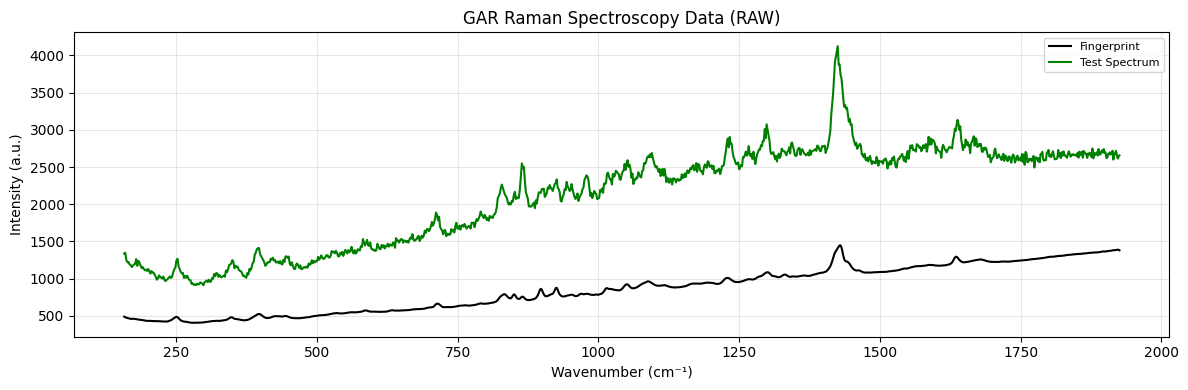

Saved preprocessed spectra data at data\tripeptides\GAR\data.npz
Saved preprocessed test spectrum data at data\tripeptides\GAR\test_spectrum.npz


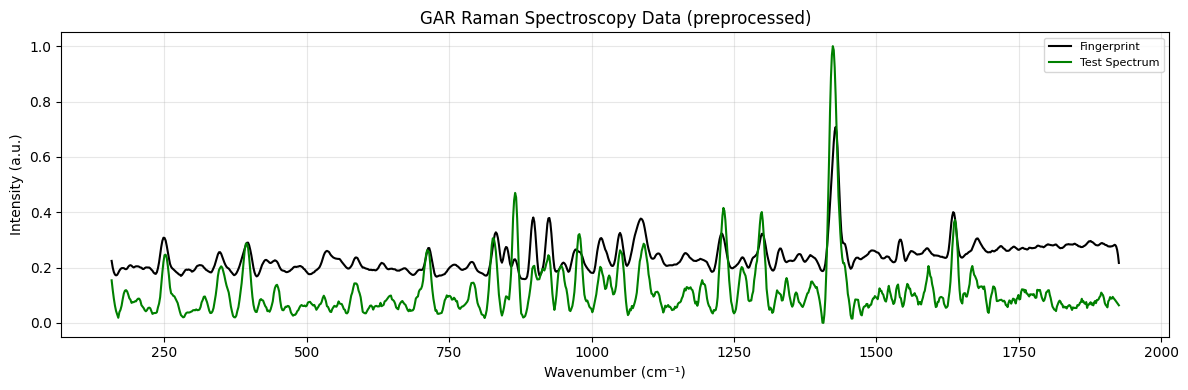

Saved fingerprint data at data\tripeptides\GAR\fingerprint.npz


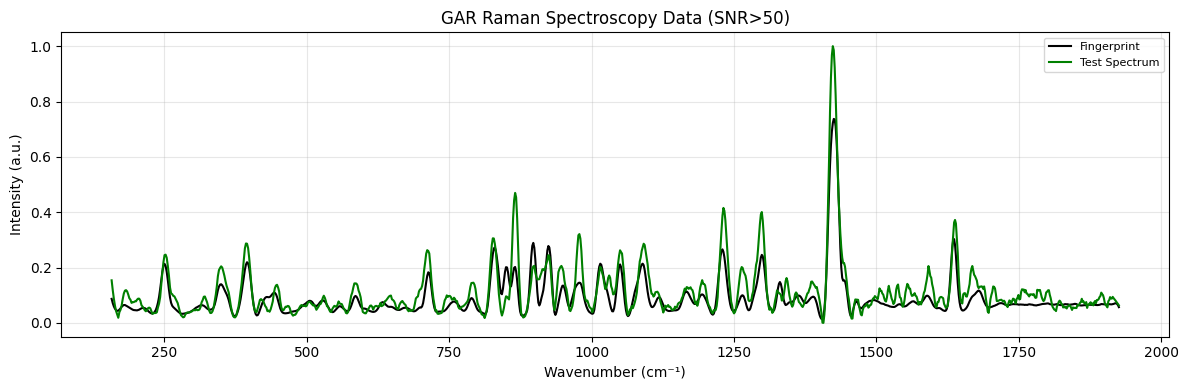

In [3]:
name = 'GAR'
process_pipeline(name, save_dir=Path('./data/tripeptides'))

## SRA (Serine-Arginine-Alanine)

SRA: 1558 spectra loaded
Saved spectra data at data\tripeptides\SRA\raw_data.npz
Test spectrum is loaded for SRA
Saved test spectrum data at data\tripeptides\SRA\raw_test_spectrum.npz


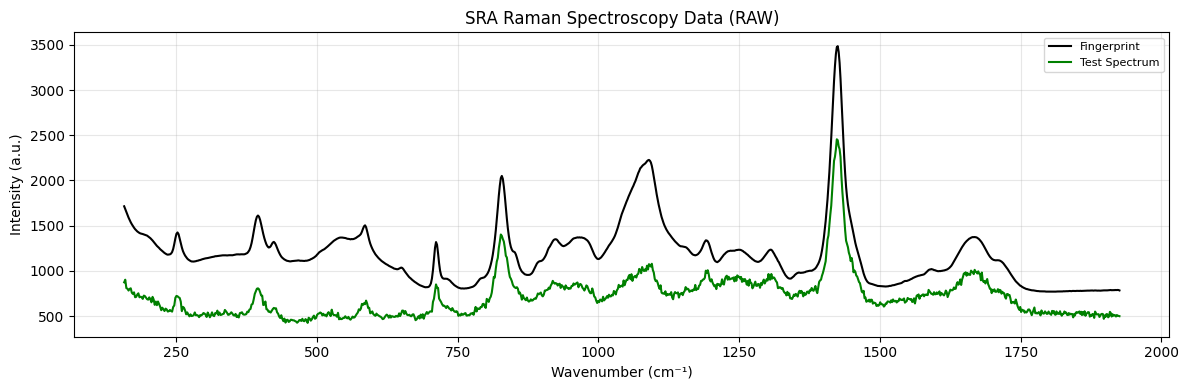

Saved preprocessed spectra data at data\tripeptides\SRA\data.npz
Saved preprocessed test spectrum data at data\tripeptides\SRA\test_spectrum.npz


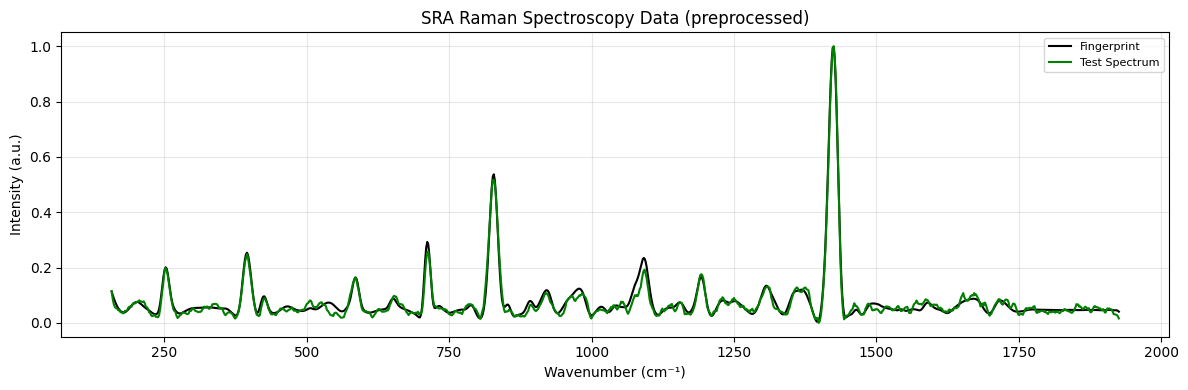

Saved fingerprint data at data\tripeptides\SRA\fingerprint.npz


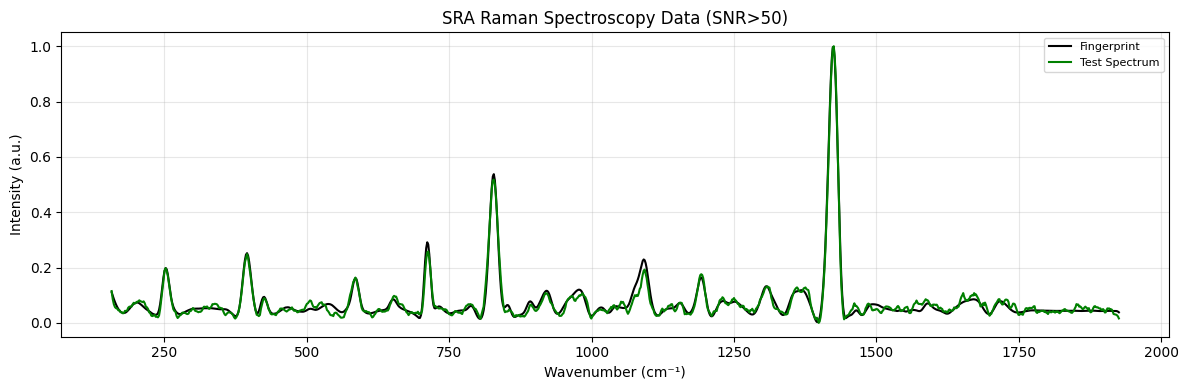

In [4]:
name = 'SRA'
process_pipeline(name, save_dir=Path('./data/tripeptides'))

# Summary

All tripeptide spectra have been processed and saved to `./data/tripeptides/` with the following structure:

```
data/tripeptides/
├── GAR/
│   ├── raw_data.npz
│   ├── raw_test_spectrum.npz
│   ├── data.npz
│   ├── test_spectrum.npz
│   └── fingerprint.npz
└── SRA/
```

# Superposition Analysis: Tripeptide vs. Constituent Amino Acids

Compare tripeptide spectra with the superposition of their three constituent amino acid fingerprints.

This analysis estimates how well the tripeptide spectrum can be represented as a weighted combination:
`α × AA1 + β × AA2 + γ × AA3` where `γ = 1 - α - β`

In [5]:
from scipy.optimize import minimize
from spectra.models import convert_amino_acid, AMINO_ACID_THREE_LETTER
from spectra.data.spectraio import load_from_npz
from spectra.models import SpectralPredictor

# Load the model
save_path = 'checkpoints/spectral_transformer_final.pt'
predictor = SpectralPredictor.load(save_path)
print("Model loaded successfully!")
label_names = predictor.label_mapping

# Tripeptide to amino acid mapping
TRIPEPTIDE_MAPPING = {
    'GAR': ('G', 'A', 'R'),  # Glycine-Alanine-Arginine
    'SRA': ('S', 'R', 'A'),  # Serine-Arginine-Alanine
}

def plot_fingerprints(*spectra, title='Tripeptide Experiment'):
    """Plot arbitrary number of fingerprints.

    Args:
        *spectra: Variable number of (fingerprint, label) tuples.
        title: Plot title (keyword argument only).
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))

    colors = plt.cm.tab10.colors
    for i, (fg, label) in enumerate(spectra):
        if fg:
            color = colors[i % len(colors)]
            alpha = 1.0 if i == 0 else 0.6
            ax1.plot(fg.wavelengths, fg.intensities,
                     '-', color=color, linewidth=2, alpha=alpha, label=label)

    ax1.set_xlabel('Wavenumber (cm\u207b\u00b9)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title(title)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Model loaded successfully!


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [6]:
def estimate_mixture_weights(fg0, fg1, fg2, fg3):
    """
    Estimate optimal mixture weights alpha, beta such that
    alpha*fg1 + beta*fg2 + (1-alpha-beta)*fg3 is closest to fg0.

    Args:
        fg0: Mixture spectrum (Spectrum object)
        fg1: First amino acid fingerprint (Spectrum object)
        fg2: Second amino acid fingerprint (Spectrum object)
        fg3: Third amino acid fingerprint (Spectrum object)

    Returns:
        (alpha, beta, mae): Mixing weights and MAE loss
    """
    y0 = fg0.intensities
    y1 = fg1.intensities
    y2 = fg2.intensities
    y3 = fg3.intensities

    def loss(params):
        alpha, beta = params
        gamma = 1 - alpha - beta
        y_pred = alpha * y1 + beta * y2 + gamma * y3
        # Min-max normalization to [0, 1]
        y_pred = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())
        return np.mean(np.abs(y0 - y_pred))  # MAE loss

    # Constraints: alpha >= 0, beta >= 0, alpha + beta <= 1
    constraints = {'type': 'ineq', 'fun': lambda x: 1 - x[0] - x[1]}
    bounds = [(0, 1), (0, 1)]

    result = minimize(loss, x0=[0.33, 0.33], method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x[0], result.x[1], result.fun

In [9]:
def analyze_tripeptide_superposition(name, snr_threshold=50):
    """
    Analyze tripeptide spectra by comparing with superposition of constituent amino acids.
    
    Args:
        name: Tripeptide name (e.g., 'GAR', 'SRA')
        snr_threshold: SNR threshold for filtering spectra
    
    Returns:
        results: List of analysis results for each spectrum
    """
    # Get constituent amino acids
    aa1_code, aa2_code, aa3_code = TRIPEPTIDE_MAPPING[name]
    aa1 = convert_amino_acid(aa1_code, "full")
    aa2 = convert_amino_acid(aa2_code, "full")
    aa3 = convert_amino_acid(aa3_code, "full")
    
    # Get class indices for the model
    cls1, cls2, cls3 = None, None, None
    for key, value in label_names.items():
        if aa1 == value:
            cls1 = key
        if aa2 == value:
            cls2 = key
        if aa3 == value:
            cls3 = key
    
    print(f'Tripeptide: {name}')
    print(f'{aa1.capitalize()} ({aa1_code}, cls={cls1}) + {aa2.capitalize()} ({aa2_code}, cls={cls2}) + {aa3.capitalize()} ({aa3_code}, cls={cls3})\n')
    
    # Load fingerprints of constituent amino acids
    fg1 = load_from_npz(Path('./data/monopeptide/') / aa1 / 'fingerprint.npz')[0]
    fg2 = load_from_npz(Path('./data/monopeptide/') / aa2 / 'fingerprint.npz')[0]
    fg3 = load_from_npz(Path('./data/monopeptide/') / aa3 / 'fingerprint.npz')[0]
    
    # Load tripeptide data
    collection = load_from_npz(Path('./data/tripeptides/') / name / 'data.npz')
    snr_values = calculate_snr(collection)
    
    idx_data = np.where(snr_values > snr_threshold)[0]
    
    print('Summary:')
    print(f'  Number of Spectra: {len(collection)}')
    print(f'  Noisy Spectra (SNR < {snr_threshold}): {len(collection) - len(idx_data)}')
    print(f'  Clean Spectra (SNR >= {snr_threshold}): {len(idx_data)}\n')
    
    # Analyze each clean spectrum
    results = []
    for id0 in idx_data:
        fg0 = collection[id0]
        alpha, beta, mae = estimate_mixture_weights(fg0, fg1, fg2, fg3)
        gamma = 1 - alpha - beta
        probs = predictor.predict_proba(fg0.intensities)[0]
        predicted_cls_ids = np.argsort(probs)[::-1][:3]
        result = {
            'id': id0,
            'snr': snr_values[id0],
            'probs': probs[predicted_cls_ids],
            'labels': predicted_cls_ids,
            'alpha': alpha,
            'beta': beta,
            'gamma': gamma,
            'mae': mae,
        }
        results.append(result)
    
    # Plot classification distribution
    first_amino = [r['labels'][0] for r in results]
    counts = np.bincount(first_amino, minlength=19)
    
    x = np.arange(19)
    plt.figure(figsize=(12, 4))
    plt.bar(x, counts, label='First Likely Amino Acid')
    plt.xticks(x, [n.capitalize() for n in label_names.values()], rotation=90)
    plt.title(f'{name} Classification Distribution')
    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Plot weight distributions
    alphas = np.array([r['alpha'] for r in results])
    betas = np.array([r['beta'] for r in results])
    gammas = np.array([r['gamma'] for r in results])
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    axes[0].hist(alphas, bins=30, edgecolor='black', alpha=0.7, color='tab:blue')
    axes[0].axvline(alphas.mean(), color='r', linestyle='--', label=f'Mean = {alphas.mean():.3f}')
    axes[0].set_xlabel(f'\u03b1 (weight of {aa1.capitalize()})')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'\u03b1 Distribution')
    axes[0].legend()
    
    axes[1].hist(betas, bins=30, edgecolor='black', alpha=0.7, color='tab:orange')
    axes[1].axvline(betas.mean(), color='r', linestyle='--', label=f'Mean = {betas.mean():.3f}')
    axes[1].set_xlabel(f'\u03b2 (weight of {aa2.capitalize()})')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'\u03b2 Distribution')
    axes[1].legend()
    
    axes[2].hist(gammas, bins=30, edgecolor='black', alpha=0.7, color='tab:green')
    axes[2].axvline(gammas.mean(), color='r', linestyle='--', label=f'Mean = {gammas.mean():.3f}')
    axes[2].set_xlabel(f'\u03b3 (weight of {aa3.capitalize()})')
    axes[2].set_ylabel('Count')
    axes[2].set_title(f'\u03b3 Distribution')
    axes[2].legend()
    
    plt.suptitle(f'{name}: Mixture Weight Distributions (\u03b1 + \u03b2 + \u03b3 = 1)', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Find representative spectrum (closest to mean weights)
    mean_alpha, mean_beta = alphas.mean(), betas.mean()
    distances = np.sqrt((alphas - mean_alpha)**2 + (betas - mean_beta)**2)
    best_idx = np.argmin(distances)
    best_result = results[best_idx]
    fg0 = collection[best_result['id']]
    alpha, beta, gamma = best_result['alpha'], best_result['beta'], best_result['gamma']
    
    # Compute superposition
    fgc_intensities = alpha * fg1.intensities + beta * fg2.intensities + gamma * fg3.intensities
    fgc_intensities = (fgc_intensities - fgc_intensities.min()) / (fgc_intensities.max() - fgc_intensities.min())
    fgc = Spectrum(np.stack((fg1.wavelengths, fgc_intensities), axis=1))
    
    # Plot comparison with all fingerprints
    plot_fingerprints(
        (fg0, f'{name} (measured)'),
        (fg1, aa1.capitalize()),
        (fg2, aa2.capitalize()),
        (fg3, aa3.capitalize()),
        title=f'{name} Tripeptide vs. Superposition (\u03b1={alpha:.2f}, \u03b2={beta:.2f}, \u03b3={gamma:.2f})'
    )
    
    # Plot just measured vs superposition
    plot_fingerprints(
        (fg0, f'{name} (measured)'),
        (fgc, f'Superposition'),
        title=f'{name}: Measured vs. Superposition (MAE = {best_result["mae"]:.4f})'
    )
    
    # Print statistics
    print(f'\nSuperposition Analysis:')
    print(f'  Mean \u03b1 ({aa1.capitalize()}): {alphas.mean():.3f} \u00b1 {alphas.std():.3f}')
    print(f'  Mean \u03b2 ({aa2.capitalize()}): {betas.mean():.3f} \u00b1 {betas.std():.3f}')
    print(f'  Mean \u03b3 ({aa3.capitalize()}): {gammas.mean():.3f} \u00b1 {gammas.std():.3f}')
    print(f'  Mean MAE: {np.mean([r["mae"] for r in results]):.4f}')
    print(f'  Best match: spectrum #{best_result["id"]} (\u03b1={alpha:.3f}, \u03b2={beta:.3f}, \u03b3={gamma:.3f}, MAE={best_result["mae"]:.4f})')
    
    return results

## GAR (Glycine-Alanine-Arginine) Superposition Analysis

Tripeptide: GAR
Glycine (G, cls=7) + Alanine (A, cls=0) + Arginine (R, cls=1)

Summary:
  Number of Spectra: 1600
  Noisy Spectra (SNR < 50): 1411
  Clean Spectra (SNR >= 50): 189



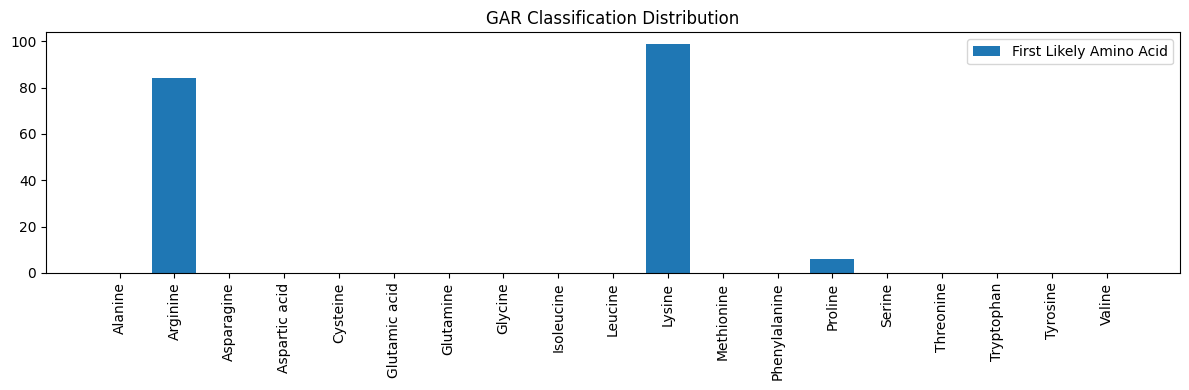

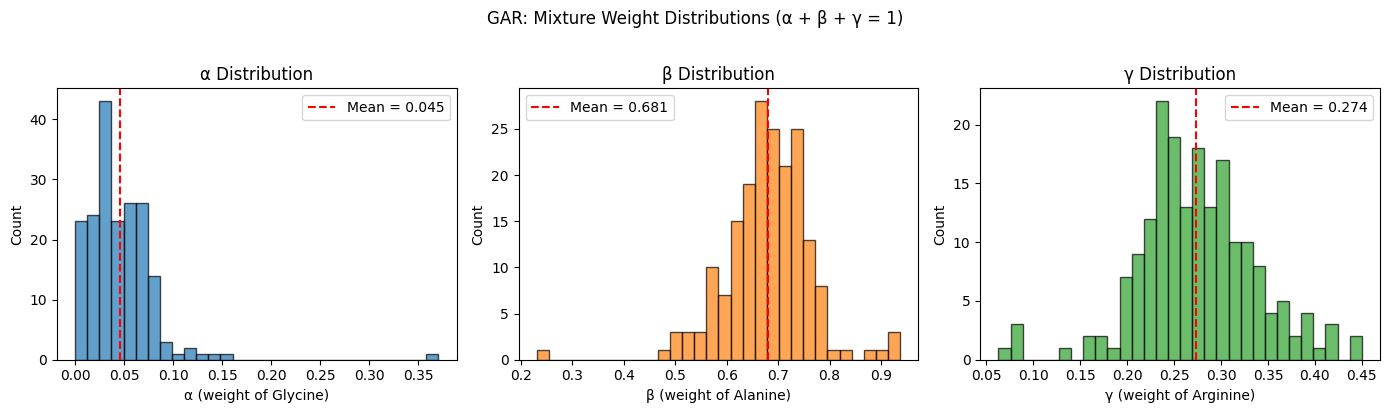

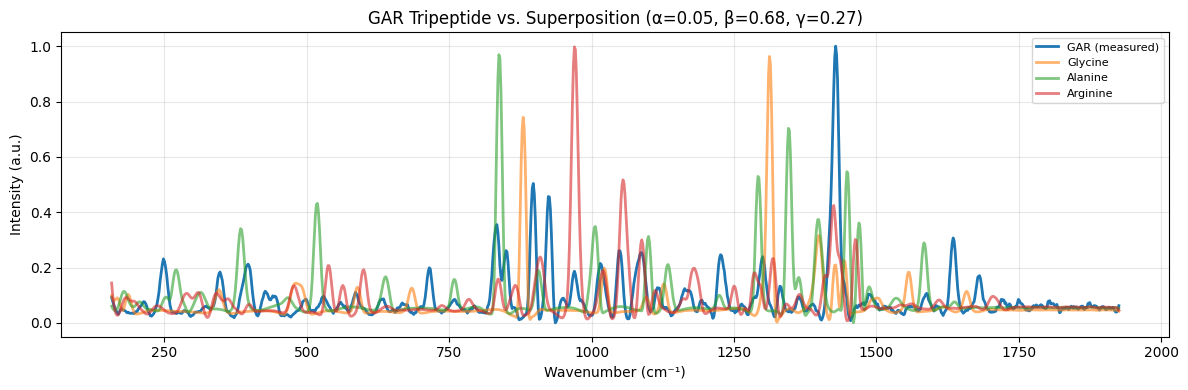

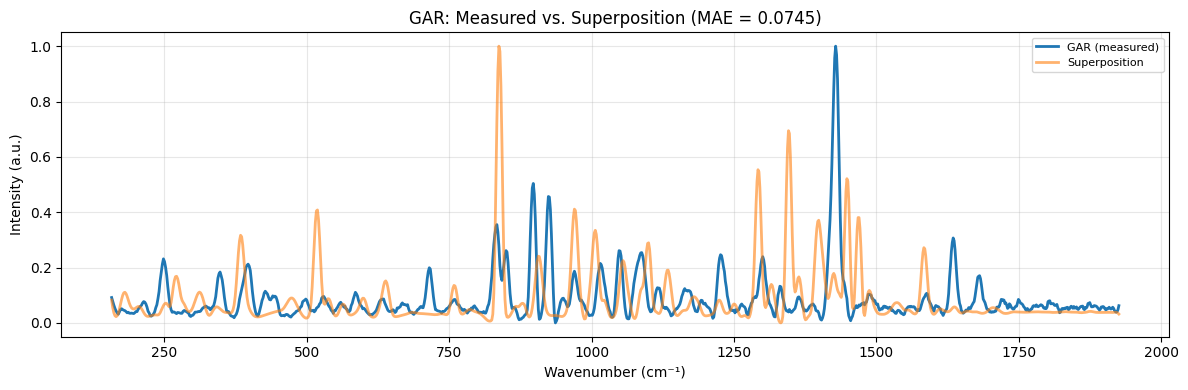


Superposition Analysis:
  Mean α (Glycine): 0.045 ± 0.037
  Mean β (Alanine): 0.681 ± 0.082
  Mean γ (Arginine): 0.274 ± 0.063
  Mean MAE: 0.0752
  Best match: spectrum #191 (α=0.045, β=0.684, γ=0.271, MAE=0.0745)


In [10]:
results_GAR = analyze_tripeptide_superposition('GAR', snr_threshold=50)

## SRA (Serine-Arginine-Alanine) Superposition Analysis

Tripeptide: SRA
Serine (S, cls=14) + Arginine (R, cls=1) + Alanine (A, cls=0)

Summary:
  Number of Spectra: 1558
  Noisy Spectra (SNR < 50): 88
  Clean Spectra (SNR >= 50): 1470



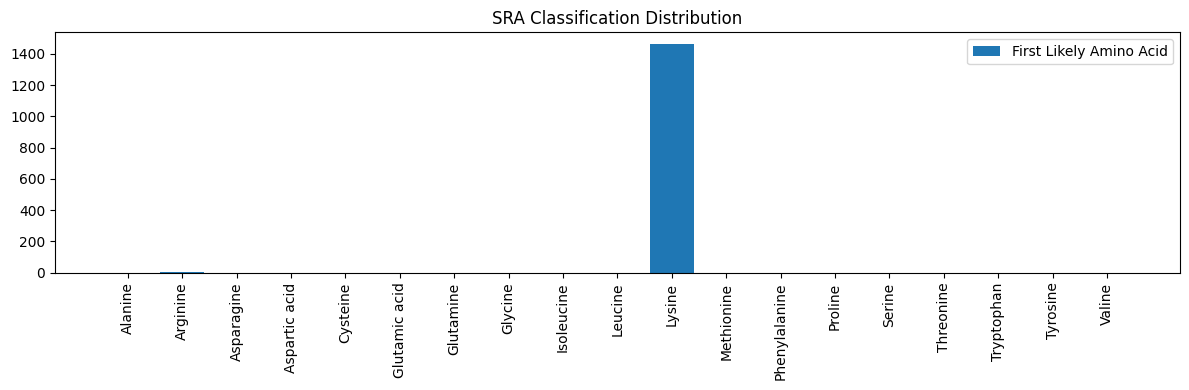

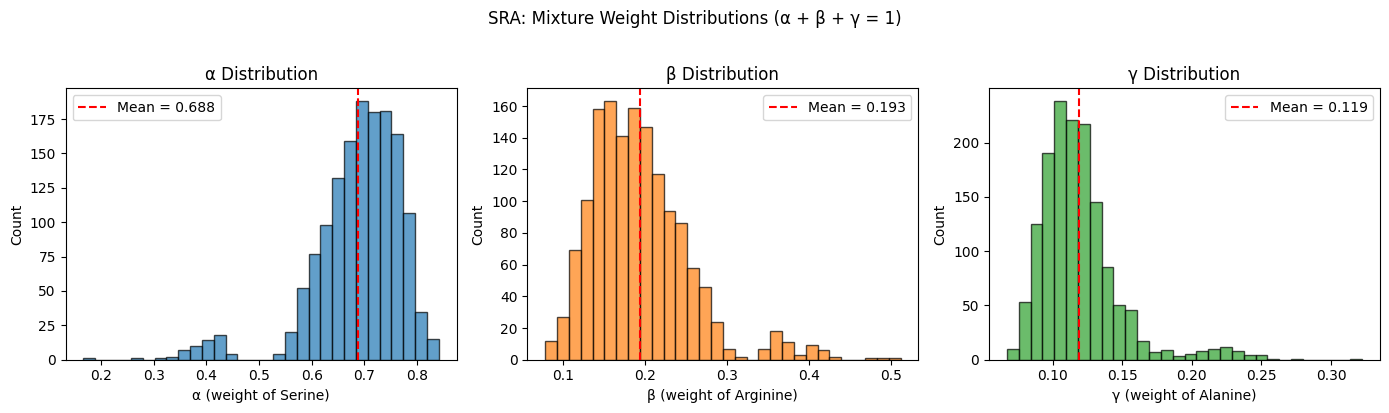

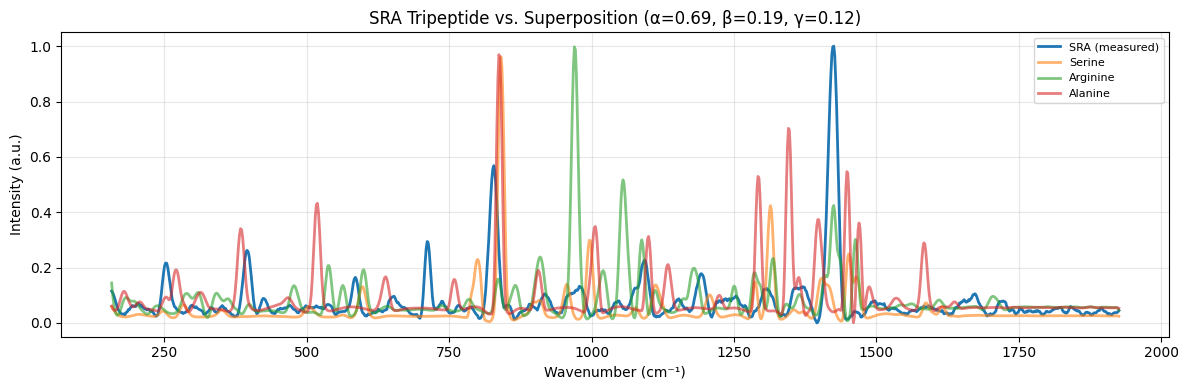

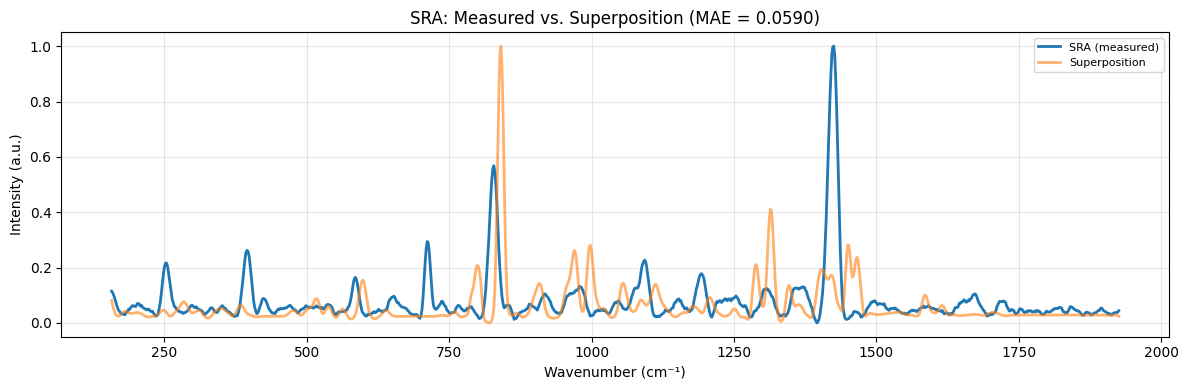


Superposition Analysis:
  Mean α (Serine): 0.688 ± 0.085
  Mean β (Arginine): 0.193 ± 0.060
  Mean γ (Alanine): 0.119 ± 0.029
  Mean MAE: 0.0584
  Best match: spectrum #1374 (α=0.687, β=0.193, γ=0.120, MAE=0.0590)


In [11]:
results_SRA = analyze_tripeptide_superposition('SRA', snr_threshold=50)

## Superposition Analysis Summary

In [12]:
# Summary statistics for all tripeptides
summary_data = []
for name, results in [('GAR', results_GAR), ('SRA', results_SRA)]:
    aa1_code, aa2_code, aa3_code = TRIPEPTIDE_MAPPING[name]
    aa1 = convert_amino_acid(aa1_code, "full")
    aa2 = convert_amino_acid(aa2_code, "full")
    aa3 = convert_amino_acid(aa3_code, "full")
    
    alphas = np.array([r['alpha'] for r in results])
    betas = np.array([r['beta'] for r in results])
    gammas = np.array([r['gamma'] for r in results])
    maes = np.array([r['mae'] for r in results])
    
    summary_data.append({
        'Tripeptide': name,
        'AA1': aa1.capitalize(),
        'AA2': aa2.capitalize(),
        'AA3': aa3.capitalize(),
        'Mean \u03b1': f'{alphas.mean():.3f}',
        'Mean \u03b2': f'{betas.mean():.3f}',
        'Mean \u03b3': f'{gammas.mean():.3f}',
        'Mean MAE': f'{maes.mean():.4f}',
        'N Spectra': len(results)
    })

# Display as table
print("Superposition Analysis Summary")
print("=" * 100)
print(f"{'Tripeptide':<12} {'AA1':<10} {'AA2':<10} {'AA3':<10} {'Mean \u03b1':<10} {'Mean \u03b2':<10} {'Mean \u03b3':<10} {'Mean MAE':<12} {'N':<6}")
print("-" * 100)
for row in summary_data:
    print(f"{row['Tripeptide']:<12} {row['AA1']:<10} {row['AA2']:<10} {row['AA3']:<10} {row['Mean \u03b1']:<10} {row['Mean \u03b2']:<10} {row['Mean \u03b3']:<10} {row['Mean MAE']:<12} {row['N Spectra']:<6}")
print("=" * 100)
print("\nNote: \u03b1, \u03b2, \u03b3 represent weights of each amino acid in the superposition model (\u03b1 + \u03b2 + \u03b3 = 1).")
print("Lower MAE indicates better fit between measured tripeptide spectrum and superposition.")

Superposition Analysis Summary
Tripeptide   AA1        AA2        AA3        Mean α     Mean β     Mean γ     Mean MAE     N     
----------------------------------------------------------------------------------------------------
GAR          Glycine    Alanine    Arginine   0.045      0.681      0.274      0.0752       189   
SRA          Serine     Arginine   Alanine    0.688      0.193      0.119      0.0584       1470  

Note: α, β, γ represent weights of each amino acid in the superposition model (α + β + γ = 1).
Lower MAE indicates better fit between measured tripeptide spectrum and superposition.
